In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("josephinelsy/spotify-top-hit-playlist-2010-2022")

print("Path to dataset files:", path)

Path to dataset files: /Users/mac/.cache/kagglehub/datasets/josephinelsy/spotify-top-hit-playlist-2010-2022/versions/3


In [3]:
import os

folder_path = '/Users/mac/.cache/kagglehub/datasets/josephinelsy/spotify-top-hit-playlist-2010-2022/versions/3'
files = os.listdir(folder_path)
print(files)


['playlist_2010to2023.csv']


In [4]:
import pandas as pd

csv_path = '/Users/mac/.cache/kagglehub/datasets/josephinelsy/spotify-top-hit-playlist-2010-2022/versions/3/playlist_2010to2023.csv'
df = pd.read_csv(csv_path, encoding='latin1')

print(df.head())


                                        playlist_url  year  \
0  https://open.spotify.com/playlist/37i9dQZF1DWU...  2000   
1  https://open.spotify.com/playlist/37i9dQZF1DWU...  2000   
2  https://open.spotify.com/playlist/37i9dQZF1DWU...  2000   
3  https://open.spotify.com/playlist/37i9dQZF1DWU...  2000   
4  https://open.spotify.com/playlist/37i9dQZF1DWU...  2000   

                 track_id              track_name  track_popularity  \
0  6naxalmIoLFWR0siv8dnQQ  Oops!...I Did It Again                81   
1  2m1hi0nfMR9vdGC8UcrnwU    All The Small Things                83   
2  3y4LxiYMgDl4RethdzpmNe                 Breathe                66   
3  0v1XpBHnsbkCn7iJ9Ucr1l            It's My Life                81   
4  62bOmKYxYg7dhrC6gH9vFn             Bye Bye Bye                75   

                     album               artist_id     artist_name  \
0  Oops!... I Did It Again  26dSoYclwsYLMAKD3tpOr4  Britney Spears   
1       Enema Of The State  6FBDaR13swtiWwGhX1WQsP       bli

In [5]:
print(f"Total number of songs in the dataset: {df.shape[0]}") # lets print the total number of songs in data
# 2400
print(f"Total number of colums in dataset: {df.shape[1]}") # lets print number of columns

Total number of songs in the dataset: 2400
Total number of colums in dataset: 23


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   playlist_url       2400 non-null   object 
 1   year               2400 non-null   int64  
 2   track_id           2400 non-null   object 
 3   track_name         2400 non-null   object 
 4   track_popularity   2400 non-null   int64  
 5   album              2400 non-null   object 
 6   artist_id          2400 non-null   object 
 7   artist_name        2400 non-null   object 
 8   artist_genres      2400 non-null   object 
 9   artist_popularity  2400 non-null   int64  
 10  danceability       2400 non-null   float64
 11  energy             2400 non-null   float64
 12  key                2400 non-null   int64  
 13  loudness           2400 non-null   float64
 14  mode               2400 non-null   int64  
 15  speechiness        2400 non-null   float64
 16  acousticness       2400 

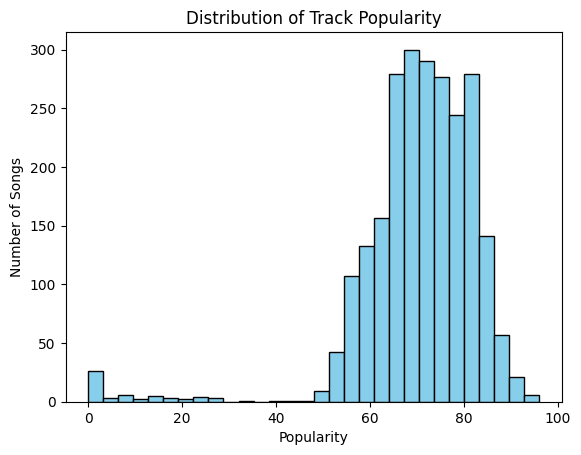

In [6]:
# 1. Basic info about data
print(df.info()) # will give us information about the dataset like colums name and how many element are there in colums

# 2. Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Summary statistics for numeric columns
print("\nSummary statistics:")
print(df.describe()) # one hell of function to describe the whole dataset

# 4. Distribution of track popularity
import matplotlib.pyplot as plt
plt.hist(df['track_popularity'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Number of Songs')
plt.show()
# there are no missing values in the data set


In [9]:
# 1. Re-create the target column (Run this first!)
# We define a 'hit' as any song with popularity >= 80
df['is_hit'] = df['track_popularity'].apply(lambda x: 1 if x >= 80 else 0)

# Check if it worked - this should print (2400,) or similar
print(df['is_hit'].shape)

(2400,)


In [11]:
# features = ['artist_popularity', 'track_popularity', 'liveness']  <-- OLD (Bad, causes leakage)

# NEW (Good) - Removing track_popularity and adding valid audio features
features = [
    'artist_popularity', 
    'liveness', 
    'danceability', 
    'energy', 
    'valence', 
    'tempo', 
    'acousticness',
    'speechiness'
]

X = df[features]
y = df['is_hit'] 

# Now re-run your train_test_split and model training cells below this!

In [24]:
df['is_hit'].value_counts()

is_hit
0    1896
1     504
Name: count, dtype: int64

In [12]:
# lets create the input and output to train the model
features = ['danceability', 'energy', 'valence', 'tempo', 'duration_ms', 'artist_popularity']
target = 'is_hit'

X = df[features] # our features having numerical values
y = df[target]   # our popularity values 0 or 1


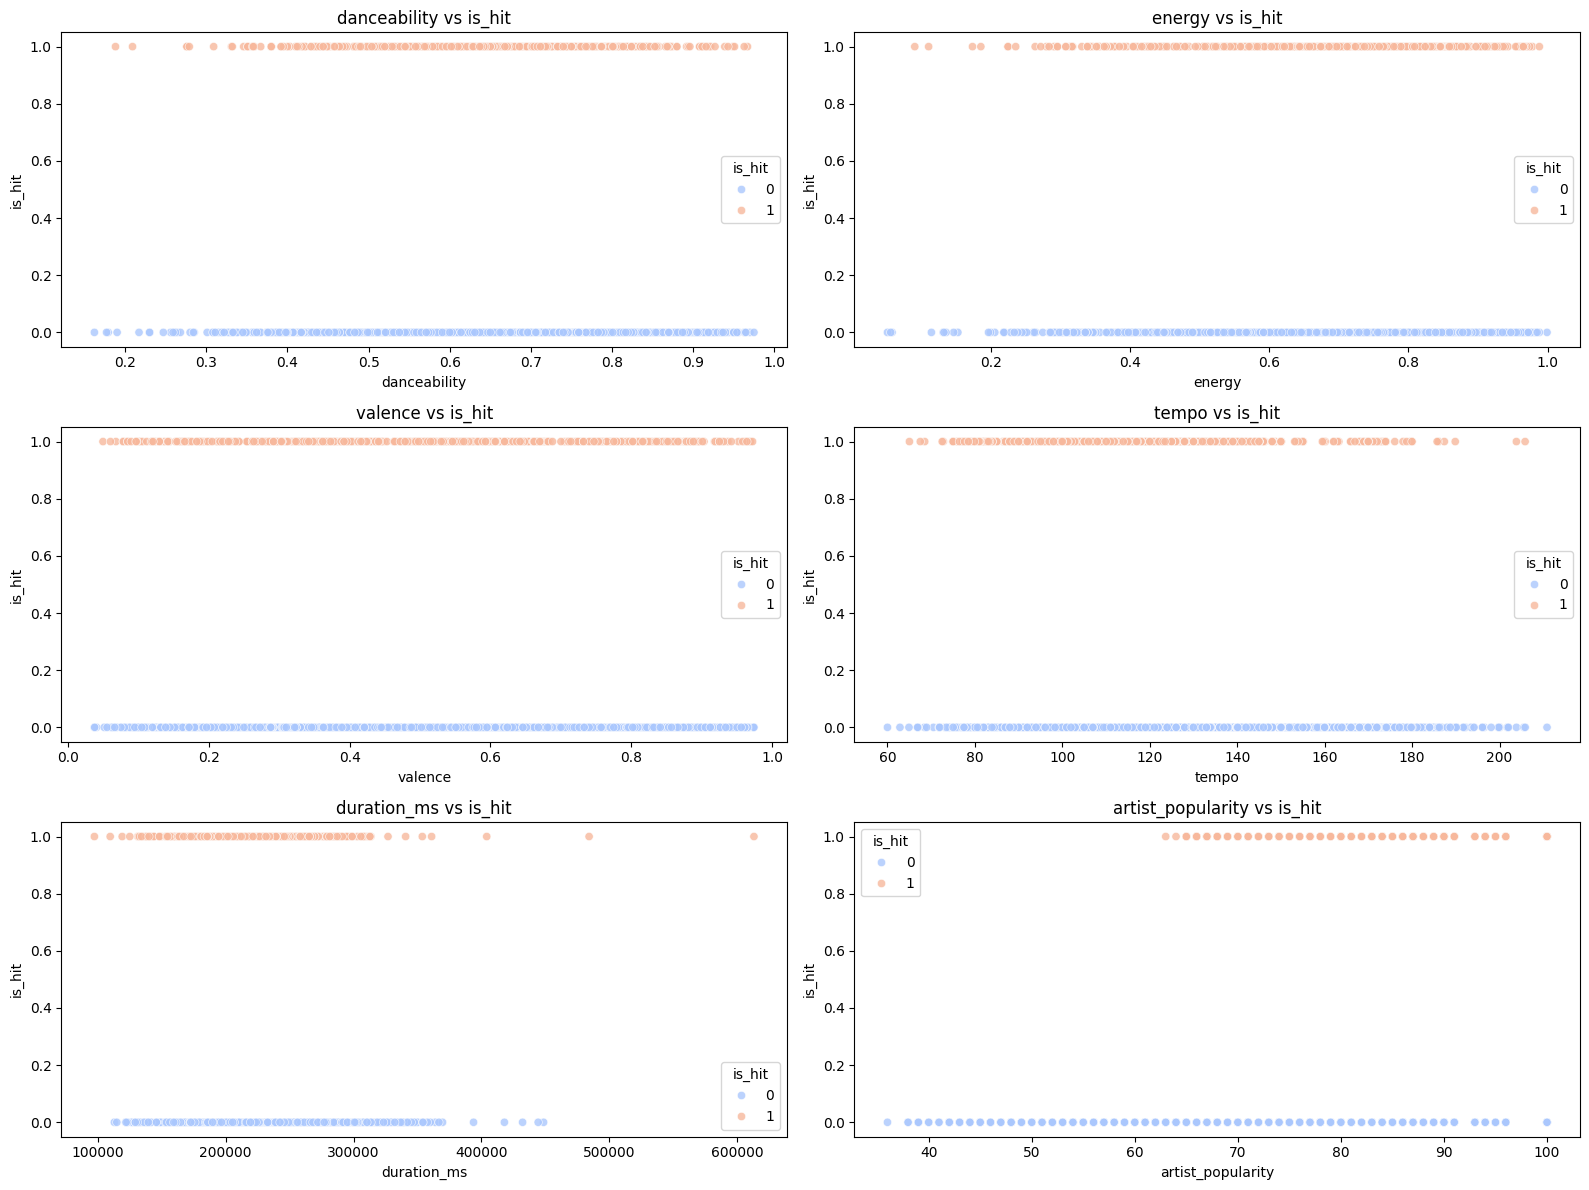

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

features = ['danceability', 'energy', 'valence', 'tempo', 'duration_ms', 'artist_popularity']

plt.figure(figsize=(16, 12))
for i, feature in enumerate(features):
    plt.subplot(3, 2, i + 1)
    sns.scatterplot(data=df, x=feature, y='is_hit', alpha=0.8, hue='is_hit', palette='coolwarm')
    plt.title(f'{feature} vs is_hit')
    plt.xlabel(feature)
    plt.ylabel('is_hit')
    plt.legend(title='is_hit', loc='best')

plt.tight_layout()
plt.show()


In [14]:
print(df[features].isnull().sum()) # will return false if there are no null values
# checking the nullvalues 

danceability         0
energy               0
valence              0
tempo                0
duration_ms          0
artist_popularity    0
dtype: int64


In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
# feature scaling 

In [25]:
# time to train the model
from sklearn.model_selection import train_test_split 

# CRITICAL FIX: Use X_scaled (your scaled data from the previous cell) instead of X
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, # <-- Use the SCALED features here
    y,
    test_size=0.2, 
    random_state=42
) 

print("Data split successfully using scaled features!")

Data split successfully using scaled features!


In [17]:
# lets choose model 
from sklearn.linear_model import LogisticRegression

In [26]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [27]:
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [28]:
# lets make prediction 
y_pred = model.predict(X_test)


In [29]:
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(model, X_scaled, y, cv=5)
print("Cross-Validation Accuracy:", cv_scores.mean())


Cross-Validation Accuracy: 0.6408333333333334


In [30]:
# evaluate the model 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.66875
Confusion Matrix:
 [[255 125]
 [ 34  66]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.67      0.76       380
           1       0.35      0.66      0.45       100

    accuracy                           0.67       480
   macro avg       0.61      0.67      0.61       480
weighted avg       0.77      0.67      0.70       480



'A confusion matrix is a table used to evaluate how well a classification model performs.\nIt compares the actual labels with the predicted labels.'

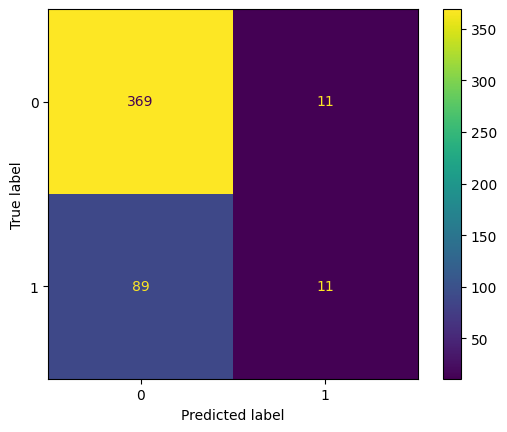

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
# what is confusion matrix 
"""A confusion matrix is a table used to evaluate how well a classification model performs.
It compares the actual labels with the predicted labels."""

In [31]:
# 369 song were corrrectly predicted as non hit 
# 89 songs were incorrectly predicted as hit but they were non hit
# 11 songs were actual hit but model mixed them 
# 11 songs were correctly predicted as hit 

--- CLASSIFICATION REPORT (Linear Regression, Tuned Threshold) ---
              precision    recall  f1-score   support

           0       0.86      0.68      0.76       380
           1       0.32      0.57      0.41       100

    accuracy                           0.65       480
   macro avg       0.59      0.62      0.58       480
weighted avg       0.74      0.65      0.68       480



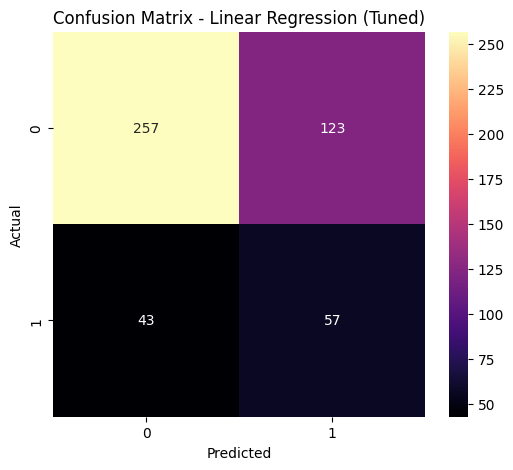

In [34]:
# linear regression

# Define features (FIXED: Removed 'track_popularity' to prevent leakage)
features = ['artist_popularity', 'liveness', 'danceability', 'energy', 'valence', 'tempo', 'acousticness', 'speechiness', 'duration_ms']
X = df[features]
y = df['is_hit'] 

# Since this block re-runs the whole process, we need to re-scale the data here.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split (FIXED: Uses scaled data)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


# Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)


# FIX 2: Fixing Imbalance Bias with a Tuned Threshold
# We must manually lower the threshold from 0.5 to fight bias against the rare 'Hits'.
# Lowering this value increases Recall (catches more Hits).
tuned_threshold = 0.25 

# Predict continuous values
y_pred_cont = lr_model.predict(X_test)

# Convert to 0 or 1 using the tuned threshold
y_pred_class = [1 if val >= tuned_threshold else 0 for val in y_pred_cont]

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix

print("--- CLASSIFICATION REPORT (Linear Regression, Tuned Threshold) ---")
print(classification_report(y_test, y_pred_class))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_class)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Linear Regression (Tuned)')
plt.show()

--- Classification Report (Random Forest Balanced) ---
              precision    recall  f1-score   support

           0       0.81      0.95      0.87       380
           1       0.44      0.15      0.22       100

    accuracy                           0.78       480
   macro avg       0.63      0.55      0.55       480
weighted avg       0.73      0.78      0.74       480



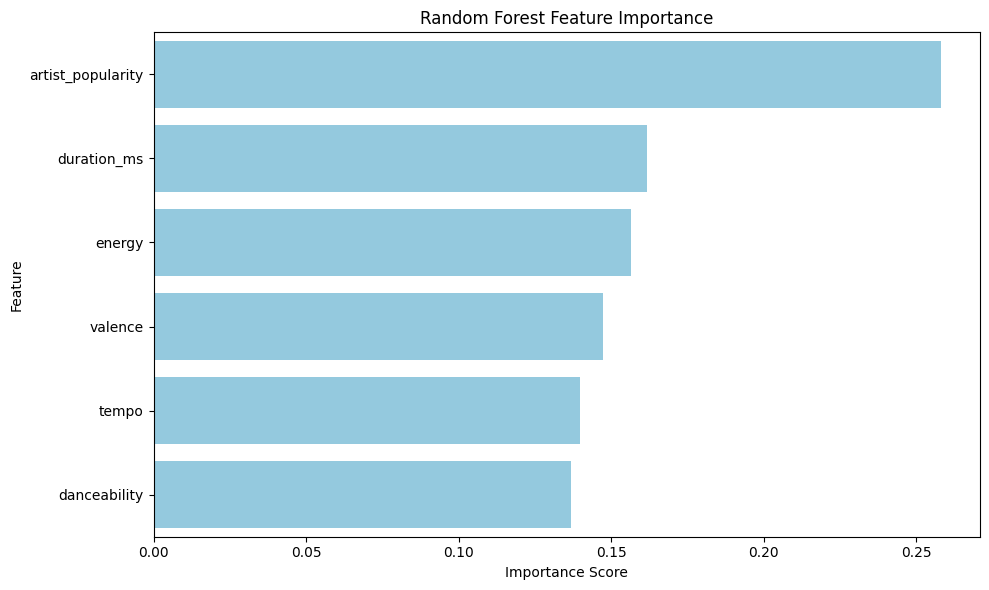

In [32]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Initialize Random Forest with balanced weights
# n_estimators=100 is the default number of trees, max_depth is set high for performance
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Train the model (using your scaled data X_train)
rf_model.fit(X_train, y_train)

# 3. Predict and Evaluate
y_pred_rf = rf_model.predict(X_test)
print("--- Classification Report (Random Forest Balanced) ---")
print(classification_report(y_test, y_pred_rf))

# 4. Plot Feature Importance (Crucial for standing out!)
feature_importances = pd.Series(
    rf_model.feature_importances_, 
    index=X.columns # Use the feature names from your X dataframe
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, color='skyblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('random_forest_feature_importance.png')
plt.show()